In [1]:
import pandas as pd   
import numpy as np 

import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
data = pd.read_csv(r"C:\Users\asus\Downloads\SMSSpamCollection.txt", sep="\t",
                    header=None,
                    names=["label", "messages"]) 
data.head()


,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
 # Exploring The Data

In [4]:
def explore_data(df):  
    ''' 
    Function for exploring the data
    '''
    print("Shape of the data:- ", df.shape) 
    print('======================================================')
    print("Non of Null values:- ", df.isnull().sum().sum()) 
    print('======================================================')
    print("Information about the data:- ", df.info())  
    print('======================================================')
    print("Describing the data:- ", df.describe())
    print('======================================================')

explore_data(data)

Shape of the data:-  (5572, 2)
Non of Null values:-  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     5572 non-null   object
 1   messages  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
Information about the data:-  None
Describing the data:-         label                messages
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


In [ ]:
# EDA

Total No. Of Ham Cases :-  4825
Total No. Of Spam Cases :-  747


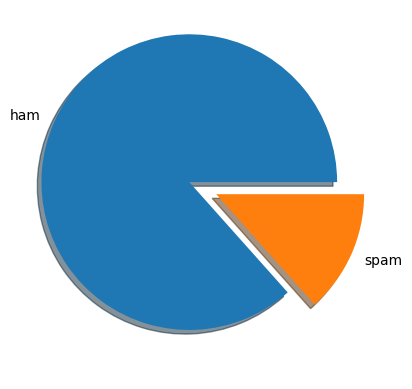

In [5]:
# seeing the distribution of classes to identify which types 

len_ham = len(data["label"][data.label == "ham"])
len_spam = len(data["label"][data.label == "spam"])

arr = np.array([len_ham , len_spam]) 
labels = ['ham', 'spam'] 
print("Total No. Of Ham Cases :- ", len_ham)
print("Total No. Of Spam Cases :- ", len_spam)

plt.pie(arr, labels=labels, explode = [0.2,0.0] , shadow=True) 
plt.show() 

In [ ]:
# Text Processing

In [6]:
def text_preprocess(x):
    x = str(x).lower()
    x = x.replace(",000,000", "m").replace(",000", "k").replace("′", "'").replace("’", "'")\
                           .replace("won't", "will not").replace("cannot", "can not").replace("can't", "can not")\
                           .replace("n't", " not").replace("what's", "what is").replace("it's", "it is")\
                           .replace("'ve", " have").replace("i'm", "i am").replace("'re", " are")\
                           .replace("he's", "he is").replace("she's", "she is").replace("'s", " own")\
                           .replace("%", " percent ").replace("₹", " rupee ").replace("$", " dollar ")\
                           .replace("€", " euro ").replace("'ll", " will") 
    return x  

data["Preprocessed Text"] = data["messages"].apply(lambda x: text_preprocess(x))
data.head()

,label,messages,Preprocessed Text
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i do not think he goes to usf, he lives ar..."


In [7]:
print(data['messages'][0]) 
print('================================================')  
print(data['Preprocessed Text'][0]) 

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...


In [ ]:
# Feature Engineering

In [8]:
data["label"] = data.label.map({'ham':0, 'spam':1})

In [ ]:
# Data Development

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['Preprocessed Text'], 
                                                    data['label'], 
                                                    random_state=1)

print('Number of rows in the total set: {}'.format(data.shape[0]))
print('Number of rows in the training set: {}'.format(X_train.shape[0]))
print('Number of rows in the test set: {}'.format(X_test.shape[0]))

Number of rows in the total set: 5572
Number of rows in the training set: 4179
Number of rows in the test set: 1393


In [10]:
from sklearn.feature_extraction.text import CountVectorizer 
# Instantiate the CountVectorizer method
count_vector = CountVectorizer()

# Fit the training data and then return the matrix
training_data = count_vector.fit_transform(X_train)

# Transform testing data and return the matrix. Note we are not fitting the testing data into the CountVectorizer()
testing_data = count_vector.transform(X_test)

In [ ]:
# Model Development

In [11]:
from sklearn.naive_bayes import MultinomialNB
naive_bayes = MultinomialNB()
naive_bayes.fit(training_data, y_train) 

MultinomialNB()

In [12]:
predictions = naive_bayes.predict(testing_data) 
predictions

array([0, 0, 0, ..., 0, 1, 0], shape=(1393,))

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('Accuracy score: ', format(accuracy_score(y_test, predictions))) 
print('Precision score: ', format(precision_score(y_test, predictions))) 
print('Recall score: ', format(recall_score(y_test, predictions))) 
print('F1 score: ', format(f1_score(y_test, predictions))) 

Accuracy score:  0.9877961234745154
Precision score:  0.9719101123595506
Recall score:  0.9351351351351351
F1 score:  0.953168044077135
